In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, opes_config, data, opes_hash, hash_configs
import json
from matplotlib.collections import LineCollection


# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


Index(['depth', 'true_age', 'cal_c14_age', 'sigma_age', 'd18O', 'sigma_d18O'], dtype='object')


In [2]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [3]:
base_dir = Path.cwd()

output_dir = base_dir / f"output/{data["dn"]}/{opes_hash}"

np.random.seed(opes_config["hmcc"]["sd"])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (opes_config["hmcc"]["nch"], data["N"]))

hmc_config = opes_config["hmcc"]

In [4]:
iData = az.from_netcdf(output_dir / f"results.nc")
samples = iData.posterior['sed_rates'].values
# bias_values = iData.sample_stats['bias_value'].values
# delF = iData.sample_stats['delta_F'].values
acceptance = iData.sample_stats['acceptance_rate'].values
energy_values = -iData.sample_stats['lp'].values

In [5]:
print(acceptance)

[[0.83210281 1.         1.         ... 0.28767652 1.         1.        ]
 [1.         0.00123502 0.5019403  ... 0.50287781 1.         1.        ]
 [0.49537139 0.86527469 0.85753409 ... 0.25825508 0.69552639 1.        ]
 [1.         0.79667538 1.         ... 1.         1.         1.        ]
 [0.33798118 1.         0.94781678 ... 0.30885842 1.         1.        ]]


In [6]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

(5, 51)


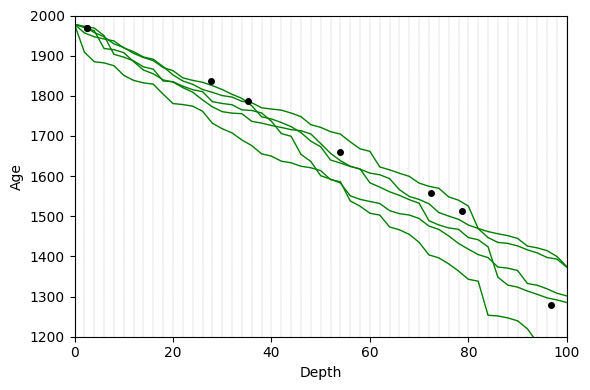

In [7]:

cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/sp_age_depth.jpg")
plt.show()

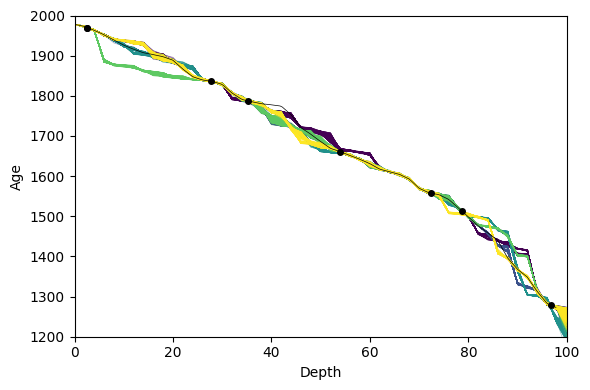

In [8]:
short_samples = samples[:, 100:, :]
cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
zeros = np.zeros((*short_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(short_samples[0,:,0])

for i in range(hmc_config["nch"]):
    lines = np.stack(
        [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
    )

    lc = LineCollection(
        lines,
        colors=colors[i],
        linewidths=0.5,
        alpha=0.5
    )
    ax.add_collection(lc)
    ax.autoscale()

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(output_dir / "age_depth_samples.jpg")

In [10]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples[:, 100:, :])
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.77   0.39    2.09     3.54       0.05     0.02     78.01    349.36   
x[1]    4.55   0.98    2.40     6.30       0.04     0.10    390.22    263.11   
x[2]    3.70   1.40    1.34     5.92       0.03     0.13   5099.35    371.55   
x[3]   11.16   3.64    2.64    14.73       0.61     0.44     49.26    227.93   
x[4]    5.59   2.73    1.28    10.01       0.10     0.25   1838.85    827.36   
x[5]    7.67   3.73    1.91    13.66       0.43     0.04     76.92    773.98   
x[6]    5.86   3.15    1.24    11.79       0.09     0.03   1241.96   6696.74   
x[7]    5.32   2.33    1.34     9.29       0.04     0.15   3200.53    599.01   
x[8]    4.43   1.91    1.27     7.67       0.03     0.16   6062.15    350.99   
x[9]    4.41   2.13    1.02     7.77       0.07     0.20   4101.81    301.99   
x[10]   4.15   2.05    1.19     7.73       0.13     0.18   1238.96    240.82   
x[11]   4.56   2.09    0.81     7.41    

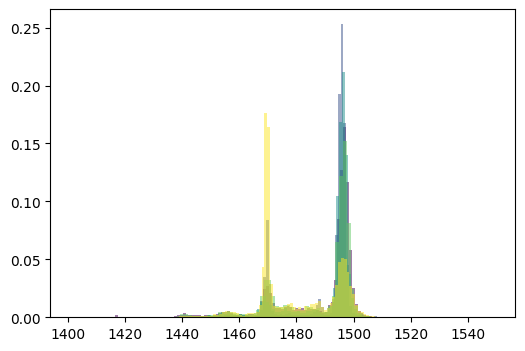

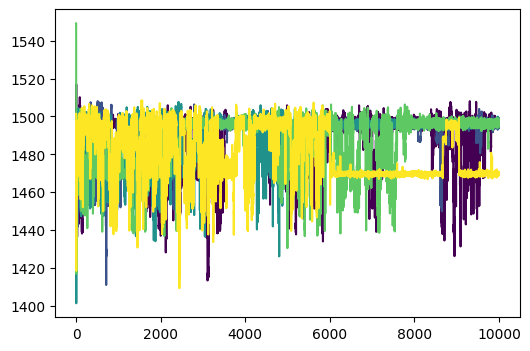

In [11]:
index = 41
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [12]:
bias_values = np.load(f"{output_dir}/bias.npy")
energy_values = np.load(f"{output_dir}/energy.npy")

In [13]:
i = np.argmin(energy_values.flatten())
print(i)
print(energy_values.flatten()[i])
print(bias_values.flatten()[i])


29519
219.2966392171677
3.2632107495238425


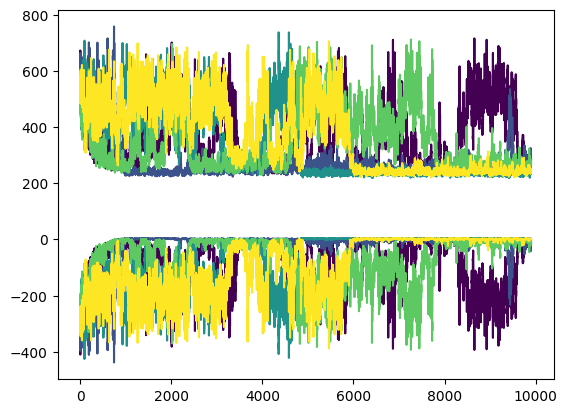

In [14]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(bias_values[i, 100:], color = colors[i])
    plt.plot(energy_values[i,100:], color = colors[i])
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [15]:
print(np.shape(energy_values))

(5, 10000)


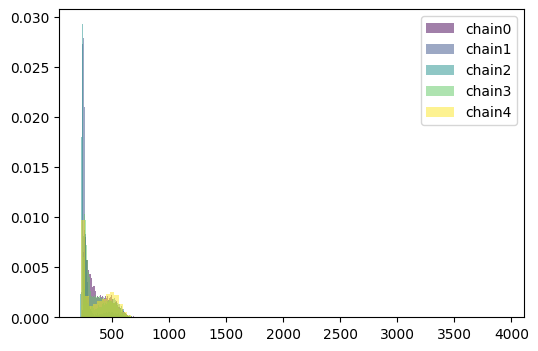

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(energy_values[i, 10:], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [17]:
resampled_samples = []
cutout = 10
weights = np.exp(bias_values)
local_indices_list = []
for i in range(hmc_config["nch"]):
    weights_i = weights[i, cutout:] / sum(weights[i, cutout:])

    indices = np.random.choice(
        np.arange(cutout, len(weights_i) + cutout),
        size=int(len(weights_i)),
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling


In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import colors

# X = resampled_samples[1].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.zeros((1, N)),
#     data["th"] - np.cumsum(X, axis=0)
# ])

# age_mean = np.mean(age, axis = 1)
# norm_age = age- age_mean.reshape(51, 1)

# # Time bins
# dt = 0.1
# t_edges = np.arange(-20, 20 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)

# # Main loop (interp1 + histcounts)
# for i in range(Z):
#     a = np.array([
#         np.interp(z[i], depth, norm_age[:, j])
#         for j in range(N)
#     ])
#     C[i, :], _ = np.histogram(a, bins=t_edges)

# # ------------------
# # Plotting
# # ------------------
# plt.figure(1, figsize=(10, 10), dpi=100)
# plt.clf()

# sub = [0.10, 0.10, 0.80, 0.80]
# plt.rcParams.update({
#     'font.size': 11,
#     'axes.labelsize': 11,
#     'xtick.labelsize': 11,
#     'ytick.labelsize': 11
# })

# plt.set_cmap(plt.cm.Oranges)

# print(np.nanmax(C))

# ax = plt.axes(sub)
# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.colorbar(im)
# plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
# plt.show()


In [19]:
d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

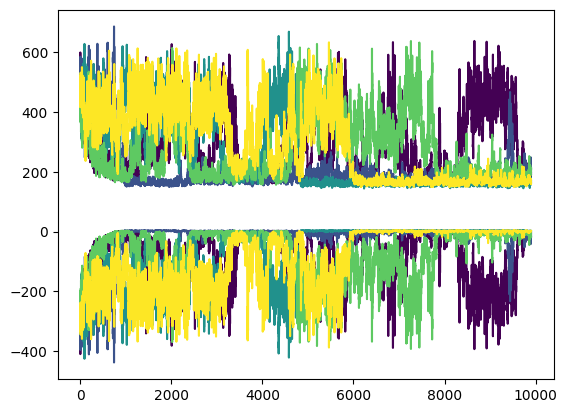

144.2562261179089


In [20]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(bias_values[i, 100:], color = colors[i])
    plt.plot(d18o_energy_values[i,100:], color = colors[i])
plt.savefig(f"{output_dir}/d18o_energy_and_bias.jpg")
plt.show()
print(np.min(d18o_energy_values))

In [21]:
print("Reweighting energies for each temp\n")
nt = opes_config["nt"]

temp_centers = np.geomspace(1, opes_config["ebt"], nt)
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
energy_samples = []
all_weights = []
cutout = 100

for j in range(nt):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - 1) * d18o_energy_values + bias_values)
    for i in range(hmc_config["nch"]):
            weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
            indices = np.random.choice(
                np.arange(cutout, len(weights_i) + cutout),
                size=int(len(weights_i)),
                replace=True,
                p=weights_i,
            )
            temp_energy_samples.append(energy_values[i, indices])

    print(f"Temp {j} done resampling")
    all_weights.append(weights)
    energy_samples.append(temp_energy_samples)

energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Temp 0 done resampling
Temp 1 done resampling
Temp 2 done resampling
Temp 3 done resampling
Temp 4 done resampling
Temp 5 done resampling
Temp 6 done resampling
Temp 7 done resampling
Temp 8 done resampling
Temp 9 done resampling
Temp 10 done resampling
Temp 11 done resampling
Temp 12 done resampling
Temp 13 done resampling
Temp 14 done resampling
Temp 15 done resampling
Temp 16 done resampling
Temp 17 done resampling
Temp 18 done resampling
Temp 19 done resampling
Temp 20 done resampling
Temp 21 done resampling
Temp 22 done resampling
Temp 23 done resampling
Temp 24 done resampling
Temp 25 done resampling
Temp 26 done resampling
Temp 27 done resampling
Temp 28 done resampling
Temp 29 done resampling
Temp 30 done resampling
Temp 31 done resampling
Temp 32 done resampling
Temp 33 done resampling
Temp 34 done resampling
Temp 35 done resampling
Temp 36 done resampling
Temp 37 done resampling
Temp 38 done resampling
Temp 39 done resampling
(40, 5, 9900)


(40, 5, 10000)


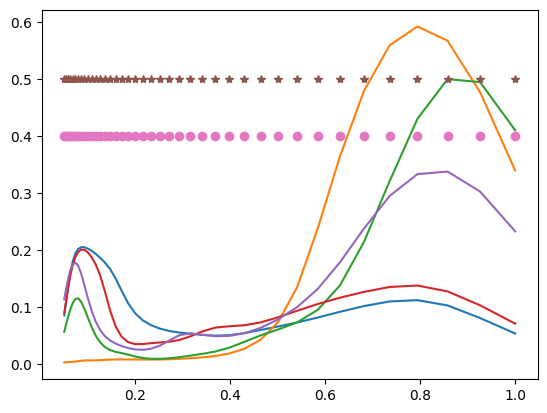

[[ 537.45418982 3396.88174016 4104.1312353   710.45776638 2330.43668135]
 [ 808.92617758 4772.32449896 4949.20484597 1032.1994409  3028.33113261]
 [1029.90847104 5674.80816957 5001.1584251  1276.24190528 3379.34258735]
 [1122.62795768 5925.07993671 4306.18933662 1379.55730291 3333.99878849]
 [1099.99444047 5594.89058906 3210.29486761 1353.88751891 2951.2725289 ]
 [1018.38675487 4788.52463561 2139.69933214 1267.26869783 2374.7105076 ]
 [ 918.14945741 3642.17759714 1379.65708581 1165.43629934 1785.74834193]
 [ 818.20448985 2383.73717179  952.89559258 1055.68619121 1319.8201763 ]
 [ 731.49672108 1356.38718016  734.51916123  937.67896822 1002.74062598]
 [ 661.72815727  740.59577175  609.12440188  822.99559714  786.94049942]
 [ 600.07314928  428.00272545  505.37379385  732.91710209  636.97288474]
 [ 544.29910908  270.40252937  391.93325592  682.67691864  542.50178804]
 [ 507.84126985  187.47217138  289.1371192   664.83954392  496.13283075]
 [ 499.95704854  143.02370851  221.42540767  641.33

In [22]:
print(np.shape(np.array(all_weights)))
all_weights = np.array(all_weights)
n_eff = np.sum(all_weights, axis = 2)**2 / np.sum(all_weights**2, axis = 2)
plt.figure()
plt.plot(betas, n_eff / hmc_config["ns"])
plt.plot(betas, 0.5*np.ones_like(betas), '*')
plt.plot(1/ np.geomspace(1, opes_config["ebt"], opes_config["nt"]), 0.4*np.ones_like(betas), 'o')
plt.show()
print(n_eff)
print(betas)
print(len(1/ np.geomspace(1, opes_config["ebt"], opes_config["nt"])))
print(len(betas))

In [23]:
# limit_grid = np.linspace(80, 190, 100)
# bin_grid = limit_grid[:-1]
# mean_energies = np.zeros((hmc_config["nch"], nt))
# energy_stds = np.zeros((hmc_config["nch"], nt))

# for k in range(hmc_config["nch"]):
#     fig, ax = plt.subplots(figsize=(6, 4))
#     for j in range(nt):
#         ax.hist(energy_samples[j, k], bins = 100, color = temp_colors[j], label = f"temp {temp_centers[j]}", alpha = 0.5, density = True)
#         mean_energies[k,j]  = np.mean(energy_samples[j, k])
#         energy_stds[k,j]  = np.std(energy_samples[j, k])
    
#     plt.savefig(f"{output_dir}/temp_pic_chain_{k}.jpg")
#     plt.show()

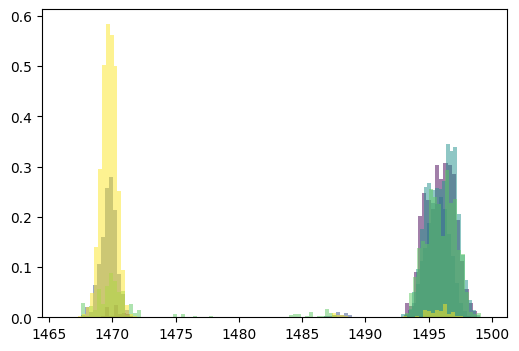

In [24]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))

CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/resampling_along_depth_{interesting_depth}.jpg")
plt.show()

In [25]:
short_resampled_samples = resampled_samples[:, :, :]
cumulative_sums = np.cumsum(short_resampled_samples, axis=2) * data["dc"]
zeros = np.zeros((*short_resampled_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets
num_samples = len(short_resampled_samples[0,:,0])


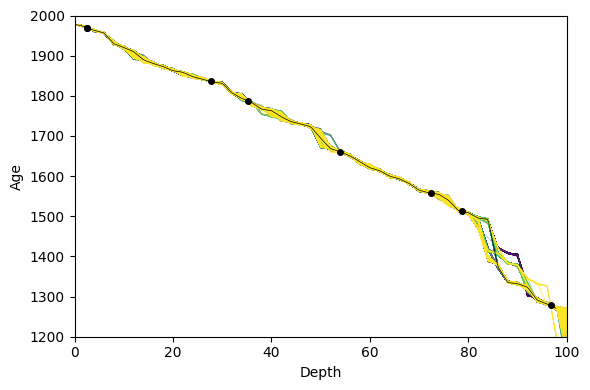

In [26]:

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    lines = np.stack(
        [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
    )

    lc = LineCollection(
        lines,
        colors=colors[i],
        linewidths=0.5,
        alpha=0.5
    )
    ax.add_collection(lc)
    ax.autoscale()

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth.jpg")
# plt.show()

In [27]:
base_dir = Path.cwd()

df = np.load(f"{output_dir}/df.npy")
print(df.shape)

(5, 10000, 40)


In [28]:
print(np.max(df[1, 3500:4500, 5]))
print(np.min(df[1, 3500:4500, 5]))
print(df[1, 0, 5])
print(np.shape(df))

-54.74767830950041
-54.91563652972918
-44.648107249040464
(5, 10000, 40)


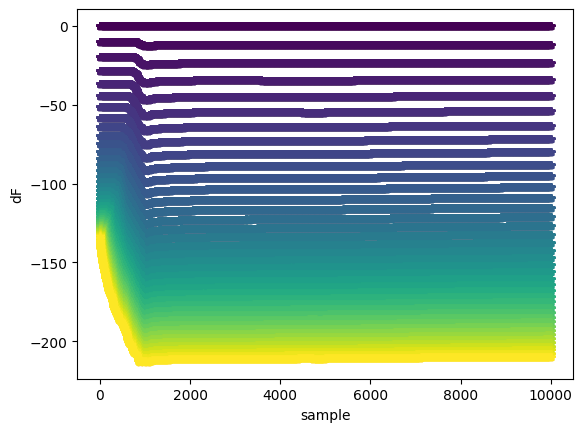

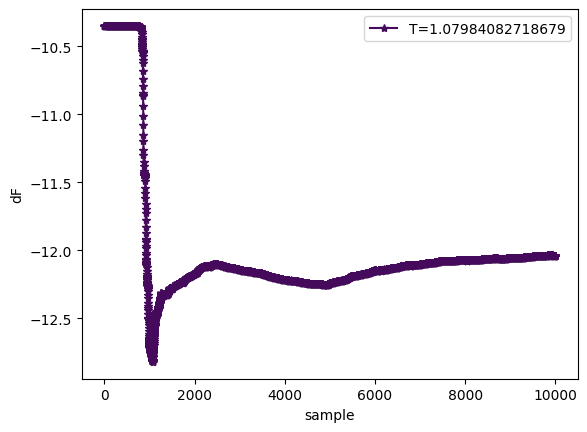

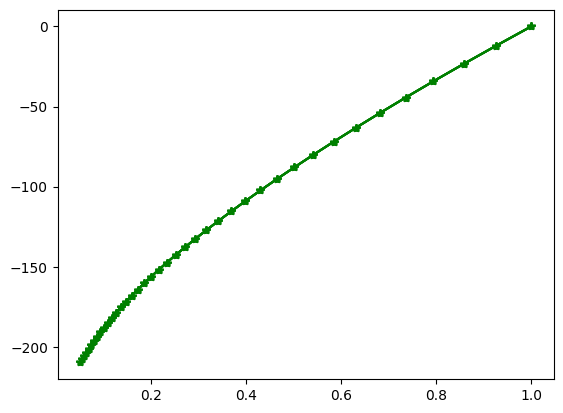

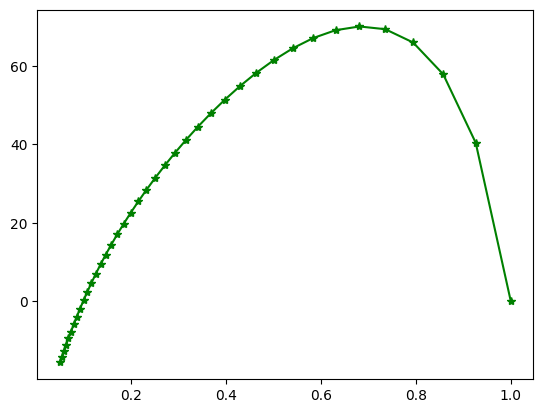

In [29]:
fig, ax = plt.subplots()
chain = 0

x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
for k in range(nt):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

plt.xlabel(f"sample")
plt.ylabel("dF")
plt.savefig(f"{output_dir}/df.jpg")
plt.show()

fig, ax = plt.subplots()
sample_delta_F = np.squeeze(df[chain, :, 1])
ax.plot(x, sample_delta_F, '*-', color = temp_colors[1], label = f"T={temp_centers[1]}")
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(f"dF")
plt.savefig(f"{output_dir}/df_last.jpg")
plt.show()

plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(betas, df[i, -1, :], marker = '*', color = "green")

plt.savefig(f"{output_dir}/df_to_beta.jpg")
plt.show()

other_df = np.load("C:/Users/hanna/Desktop/PhD/Bacon/python/src/age_depth_models/age_depth_model_OPES_normal_clean_d18o_stable/output/dayu06/sd_1000/d6ffbbe875/df.npy")
plt.figure()
plt.plot(betas, df[0, -1, :] - other_df[0, -1, :], marker = '*', color = "green")

plt.savefig(f"{output_dir}/df_to_beta_compare.jpg")
plt.show()
